# Data Augumentation Chapter 9 Workshop 3

## Load module

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, AvgPool2D


## Define Path and Input shape

In [4]:
train_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\train_set'
test_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\test_set'
val_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\val_set'

target_img_shape = (64,64)

## Prepare image

In [8]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.15,
                                   height_shift_range=0.15,
                                   shear_range=0.9,         # แนวเฉือน
                                   zoom_range=0.2,
                                   horizontal_flip=True,    # พลิกแนวนอน
                                   fill_mode='nearest')     # การเติมข้อมูลที่หายไป, pixel ภาพ
train_set = train_datagen.flow_from_directory(train_dir,
                                               target_size=target_img_shape,
                                               batch_size=32,
                                               class_mode='binary'
                                               )
     

Found 15997 images belonging to 2 classes.


## Image Visualization 

### 1 image

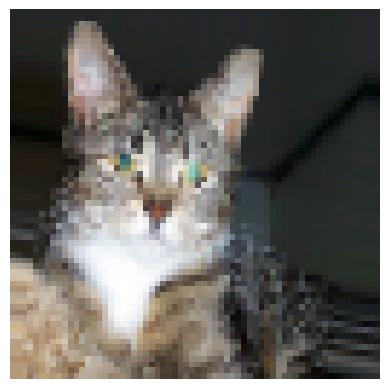

In [9]:
plt.imshow(train_set[0][0][0])
plt.axis('off')
plt.show()

### Multi image

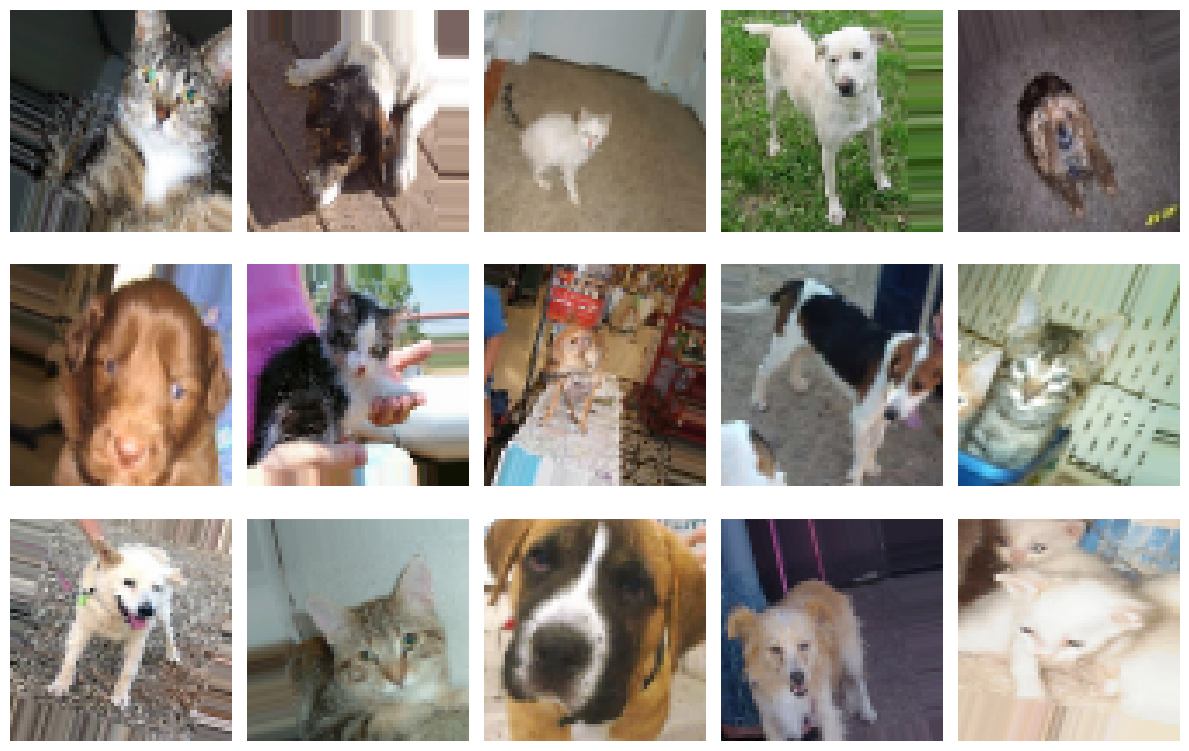

In [ ]:
nplot = 15
def plot_images(images, nplot):
    plt.figure(figsize=(12, 8))
    for i in range(nplot):
        plt.subplot(3, int(nplot/3), i+1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    
plot_images(train_set[0][0], nplot)

## Load validation data

### Define Nomaliztion

In [28]:
val_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.15,
                                   height_shift_range=0.15,
                                   shear_range=0.9,         # แนวเฉือน
                                   zoom_range=0.2,
                                   horizontal_flip=True,    # พลิกแนวนอน
                                   fill_mode='nearest')     # 

### Load data

In [29]:
val_set = val_datagen.flow_from_directory(val_dir,
                                             target_size=target_img_shape,
                                             batch_size=32,
                                             class_mode='binary')

Found 2000 images belonging to 2 classes.


## Create model VGG16

### Define input shape

In [30]:
img = train_set[0][0][0]
in_shape = (img.shape[0], img.shape[1], 3)
print('in_shape: ', in_shape) # (64, 64, 3)

in_shape:  (64, 64, 3)


### Create model

In [31]:
# model = Sequential()

# model.add(Conv2D(64, (3, 3), activation='relu', input_shape=in_shape))
# model.add(Conv2D(64, (3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Conv2D(128, (3, 3), activation='relu'))
# model.add(Conv2D(128, (3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Conv2D(256, (3, 3), activation='relu'))
# model.add(Conv2D(256, (3, 3), activation='relu'))
# model.add(Conv2D(256, (3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Flatten())
# model.add(Dense(4096, activation='relu'))
# model.add(Dense(4096, activation='relu'))
# model.add(Dense(4096, activation='relu'))

# model.add(Dense(1, activation='sigmoid'))

# model.summary()

In [32]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=in_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile model

In [33]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Traning model

In [34]:
import time
start = time.time()

history = model.fit(train_set,
                    steps_per_epoch=len(train_set),
                    epochs=20,
                    validation_data=val_set,
                    verbose=1)

end = time.time()
print('Time taken to train the model: ', (end-start)/60, 'minutes')

d:\Project\Learning\Environment_Project\tensorflow\evn1\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 110s 218ms/step - accuracy: 0.5350 - loss: 0.6893 - val_accuracy: 0.6290 - val_loss: 0.6281
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.6524 - loss: 0.6252 - val_accuracy: 0.7315 - val_loss: 0.5455
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.7029 - loss: 0.5716 - val_accuracy: 0.7295 - val_loss: 0.5363
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.7304 - loss: 0.5318 - val_accuracy: 0.7245 - val_loss: 0.5316
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.7503 - loss: 0.5110 - val_accuracy: 0.7885 - val_loss: 0.4562
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.7628 - loss: 0.4898 - val_accuracy: 0.7745 - val_loss: 0.4604
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.7830 - loss: 0.4649 - val_accuracy: 0.7950 - val_loss: 0.4316
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.7938 - loss: 0.4482 

## Loss and Accuracy Curve

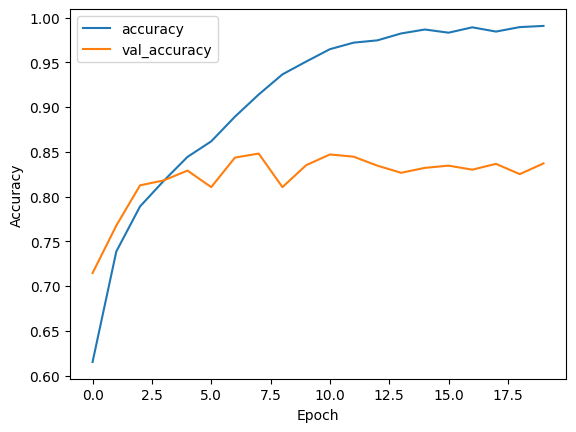

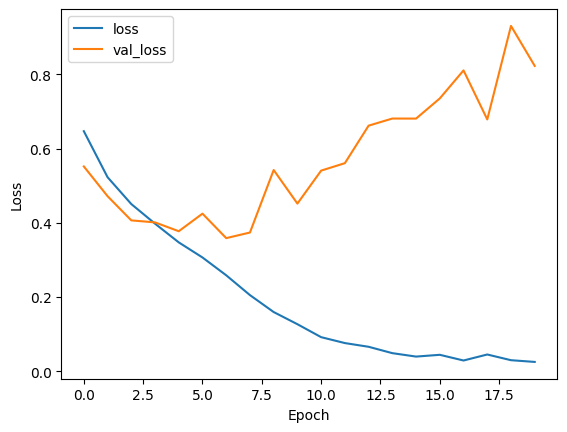

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()